## Code Implementation

In [1]:
from PIL import Image

In [2]:
def message_to_binary(message):
    binary_message = ""
    for char in message:
        binary_message += format(ord(char), '08b')
    binary_message += format(0, '08b')  
    return binary_message

def binary_to_message(binary_data):
    message = ""
    for i in range(0, len(binary_data), 8):
        byte = binary_data[i:i+8]
        if len(byte) < 8: 
            break
        char_code = int(byte, 2)
        if char_code == 0:
            break
        message += chr(char_code)
    return message

def encode_multibit_lsb(image_path, secret_message, output_path, bits_per_channel=2):
    img = Image.open(image_path).convert('RGB')
    pixels = img.load()
    width, height = img.size
    
    binary_msg = message_to_binary(secret_message)
    msg_index = 0
    msg_len = len(binary_msg)
    
    # Create a mask to clear out the last N bits. 
    # For 2 bits: 255 - 3 = 252 (Binary: 11111100)
    clear_mask = 255 - ((1 << bits_per_channel) - 1)
    
    for y in range(height):
        for x in range(width):
            if msg_index >= msg_len:
                break
                
            r, g, b = pixels[x, y]
            channels = [r, g, b]
            
            for i in range(3):
                if msg_index < msg_len:
                    # Slice out the next N bits from our binary message
                    bits_to_hide = binary_msg[msg_index : msg_index + bits_per_channel]
                    
                    # If we are at the very end and don't have enough bits left, pad with zeros
                    if len(bits_to_hide) < bits_per_channel:
                        bits_to_hide = bits_to_hide.ljust(bits_per_channel, '0')
                        
                    # 1. Clear the last N bits of the channel
                    channels[i] = channels[i] & clear_mask
                    # 2. Add our secret bits into those empty slots
                    channels[i] = channels[i] | int(bits_to_hide, 2)
                    
                    msg_index += bits_per_channel
            
            pixels[x, y] = tuple(channels)
            
        if msg_index >= msg_len:
            break
            
    img.save(output_path, "PNG")
    print(f"Message hidden successfully using {bits_per_channel}-bit LSB!")

def decode_multibit_lsb(image_path, bits_per_channel=2):
    img = Image.open(image_path).convert('RGB')
    pixels = img.load()
    width, height = img.size
    
    binary_data = ""
    # Create a mask to read the last N bits.
    # For 2 bits: (1 << 2) - 1 = 3 (Binary: 00000011)
    read_mask = (1 << bits_per_channel) - 1
    
    for y in range(height):
        for x in range(width):
            r, g, b = pixels[x, y]
            channels = [r, g, b]
            
            for i in range(3):
                # Pull the last N bits using the bitwise AND mask
                extracted_value = channels[i] & read_mask
                # Convert the number back into a binary string padded to N bits
                binary_data += format(extracted_value, f'0{bits_per_channel}b')
                
                # Check at every complete 8-bit byte if we hit our stop sign
                if len(binary_data) % 8 == 0:
                    last_byte = binary_data[-8:]
                    if int(last_byte, 2) == 0:
                        return binary_to_message(binary_data)
                        
    return binary_to_message(binary_data)

# --- Example Usage ---
if __name__ == "__main__":
    encode_multibit_lsb("input_image.jpg", "This is hidden inside multiple bits!", "multibit_encoded.png", bits_per_channel=2)
    
    decoded_text = decode_multibit_lsb("multibit_encoded.png", bits_per_channel=2)
    print(f"Decoded Message: {decoded_text}")

Message hidden successfully using 2-bit LSB!
Decoded Message: This is hidden inside multiple bits!


## Image Plotting

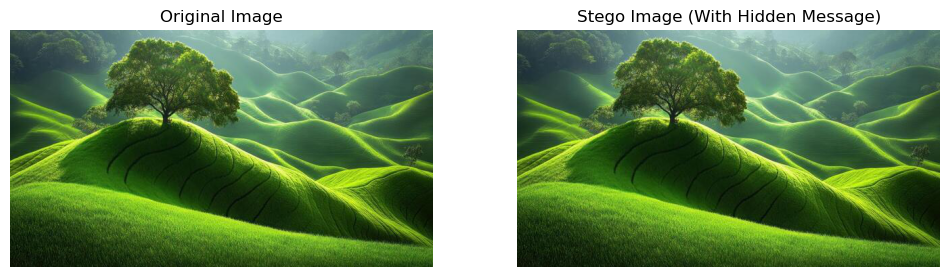

In [4]:
import matplotlib.pyplot as plt

# Load both images
original = Image.open("input_image.jpg")
stego = Image.open("multibit_encoded.png")

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(stego)
axes[1].set_title("Stego Image (With Hidden Message)")
axes[1].axis('off')

plt.show()